In [2]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
print("Library imported successfully")

Library imported successfully


In [3]:
# Cell 2: Load dataset (works both on Kaggle and locally)
DATA_PATH = '/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Titanic-Dataset.csv'   # fallback if running outside Kaggle

train = pd.read_csv(DATA_PATH)
print(train.head())
print(train.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

In [4]:
# Cell 3: Extract Title from Name BEFORE dropping Name (valuable feature)
train['Title'] = train['Name'].str.extract(r',\s*([^.]*)\.')
train['Title'] = train['Title'].replace(
    ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
     'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare'
)
train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')

print(train['Title'].value_counts())

Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64


In [8]:
# Cell 4: Feature engineering (before split, since it doesn't leak target info)
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
train['HasCabin'] = train['Cabin'].notna().astype(int)

In [9]:
# Cell 5: Drop unwanted columns (Name/Ticket/Cabin already used or not useful raw)
train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True, errors='ignore')

In [10]:
# Cell 6: Create X and y, THEN split — split BEFORE imputing/encoding to avoid leakage
X = train.drop('Survived', axis=1)
y = train['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(712, 11) (179, 11)


In [12]:
# Cell 7: Preprocessing — fit on train, apply same values to test (no leakage)
age_median = X_train['Age'].median()
fare_median = X_train['Fare'].median()
embarked_mode = X_train['Embarked'].mode()[0]

for df in (X_train, X_test):
    df['Age'] = df['Age'].fillna(age_median)
    df['Fare'] = df['Fare'].fillna(fare_median)
    df['Embarked'] = df['Embarked'].fillna(embarked_mode)

In [13]:
# Cell 8: Encode categorical features
# Sex is binary -> safe with LabelEncoder / map
sex_map = {'male': 0, 'female': 1}
X_train['Sex'] = X_train['Sex'].map(sex_map)
X_test['Sex'] = X_test['Sex'].map(sex_map)

# Embarked has 3 unordered categories -> one-hot encode, not LabelEncoder
X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Embarked'], drop_first=True)

# Title is categorical -> one-hot encode
X_train = pd.get_dummies(X_train, columns=['Title'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Title'], drop_first=True)

# Align columns in case some Title categories don't appear in test
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(X_train.shape, X_test.shape)

(712, 15) (179, 15)


In [14]:
# Cell 9: Compare models with cross-validation (more stable than a single split)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, pred)
    print(f"{name}: CV accuracy = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}), "
          f"Test accuracy = {test_acc:.4f}")

Logistic Regression: CV accuracy = 0.8175 (+/- 0.0120), Test accuracy = 0.8101
Random Forest: CV accuracy = 0.8063 (+/- 0.0452), Test accuracy = 0.8045


In [15]:
# Cell 10: Evaluate best model (Random Forest)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044692737430168


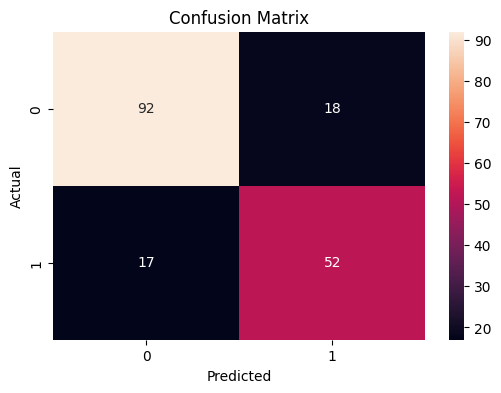

In [16]:
# Cell 11: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
# Cell 12: Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.75      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



In [18]:
# Cell 13: Feature importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

       Feature  Importance
5         Fare    0.227049
2          Age    0.207795
12    Title_Mr    0.119485
1          Sex    0.115234
0       Pclass    0.068175
6   FamilySize    0.046986
8     HasCabin    0.046941
11  Title_Miss    0.035498
13   Title_Mrs    0.033105
3        SibSp    0.030109
10  Embarked_S    0.022593
4        Parch    0.020252
7      IsAlone    0.010523
9   Embarked_Q    0.008870
14  Title_Rare    0.007384


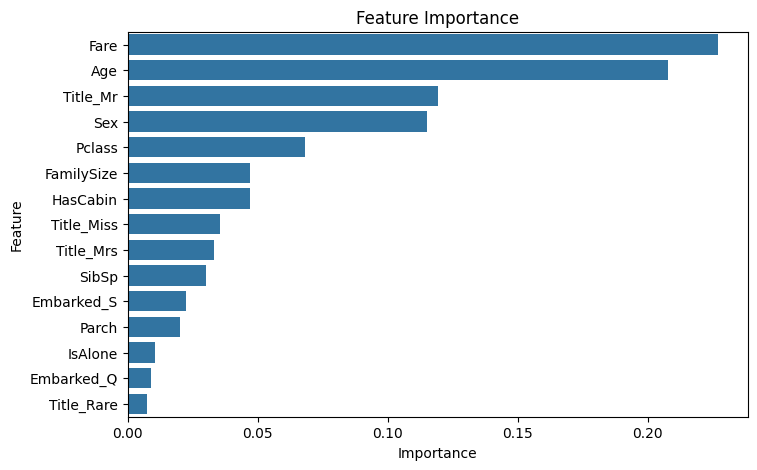

In [19]:
# Cell 14: Visualization - Feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()

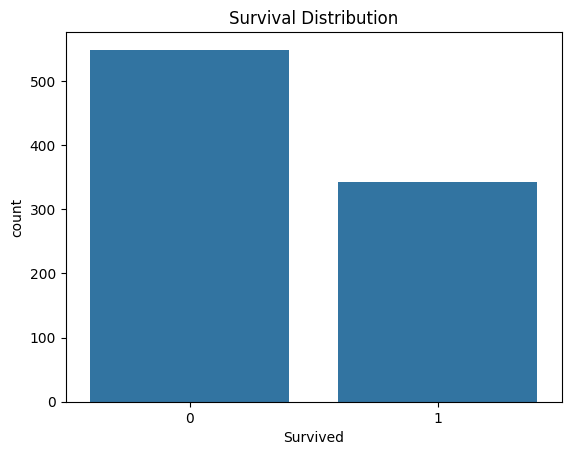

In [20]:
# Cell 15: EDA - Survival distribution (use original train df, before encoding)
sns.countplot(x='Survived', data=train)
plt.title("Survival Distribution")
plt.show()

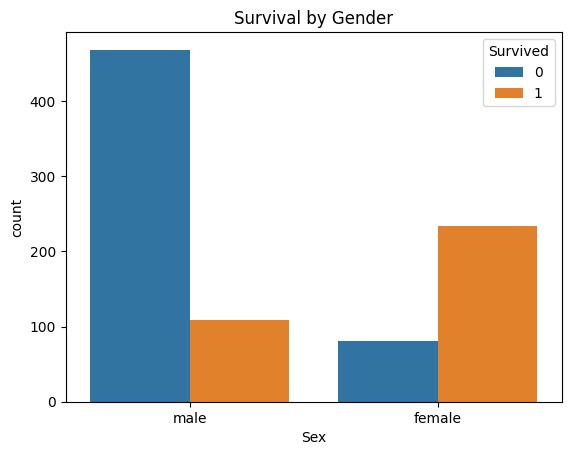

In [21]:
# Cell 16: EDA - Survival by gender
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title("Survival by Gender")
plt.show()

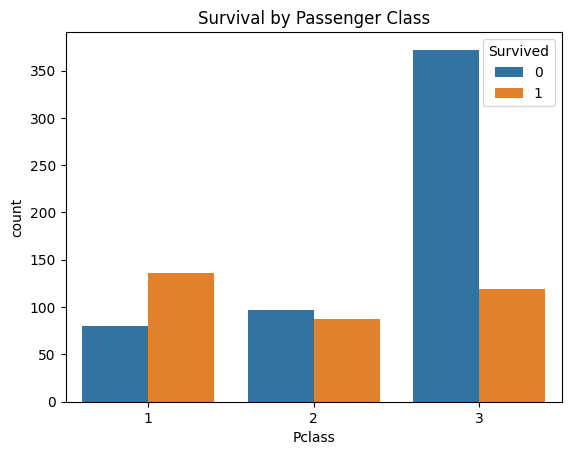

In [22]:
# Cell 17: EDA - Survival by passenger class
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title("Survival by Passenger Class")
plt.show()

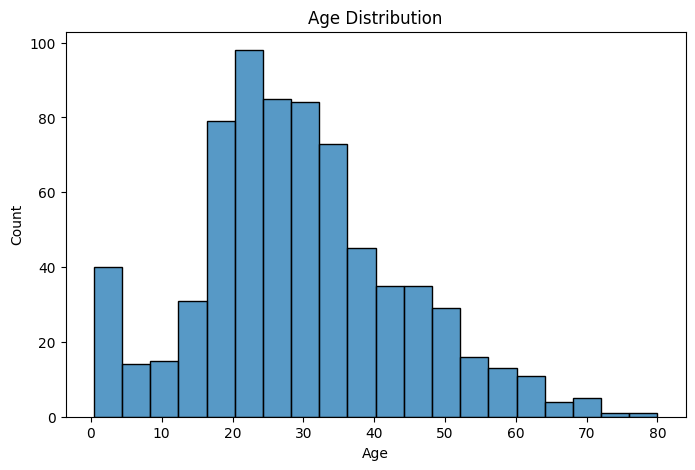

In [23]:
# Cell 18: EDA - Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(train['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

In [24]:
# Cell 19: Save model
joblib.dump(rf, 'titanic_survival_model.pkl')
print("Model Saved Successfully")

Model Saved Successfully
